Calibration parameters:
Sx:  820074.2474561329
Sy:  560741.2730406355
kx:  1.2912493813158651e-05
ky:  1.2801834934988684e-05
trapx:  -7.858806662560769e-08
trapy:  -6.621915318362614e-07


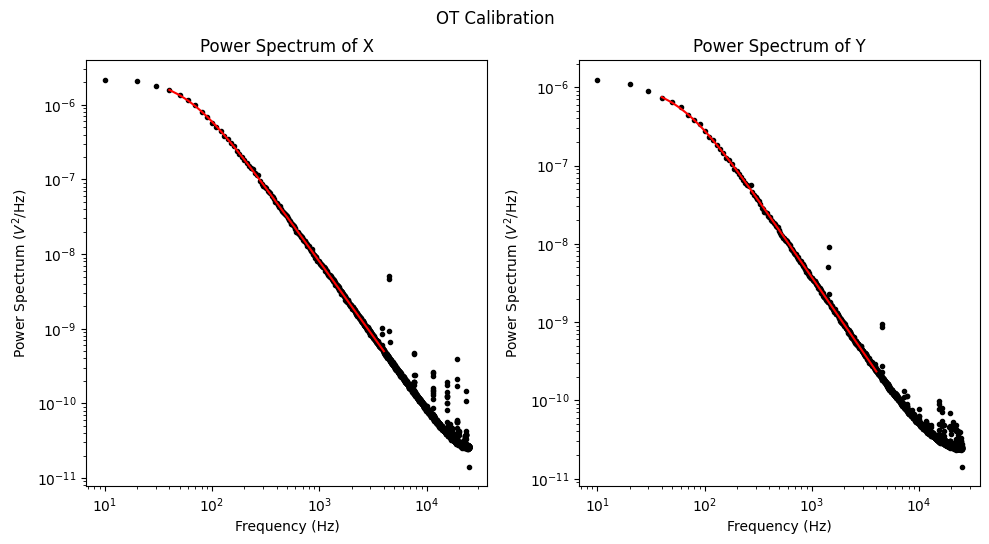

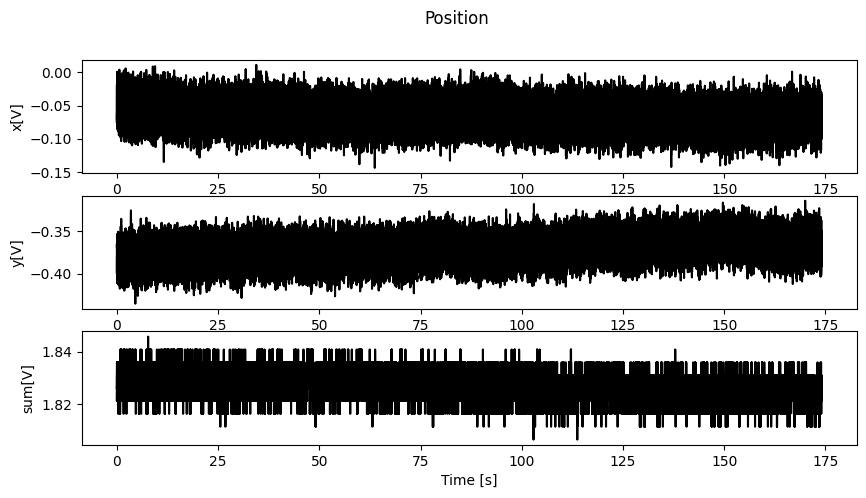

In [57]:
%reload_ext autoreload
%autoreload 2
from experiment import *

data = Active_Analysis('250226/bead3')

coeffs: [4397.33255307 6176.15861019 4441.662847    346.33676252]


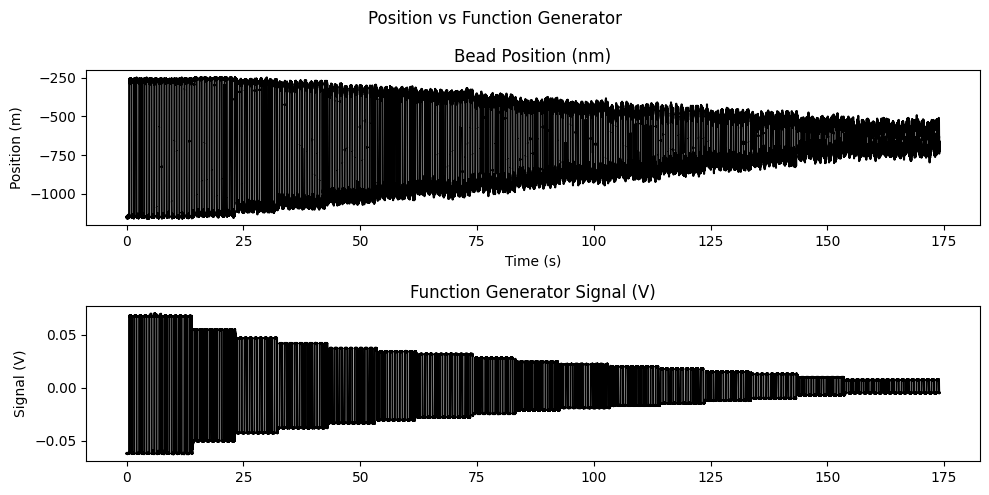

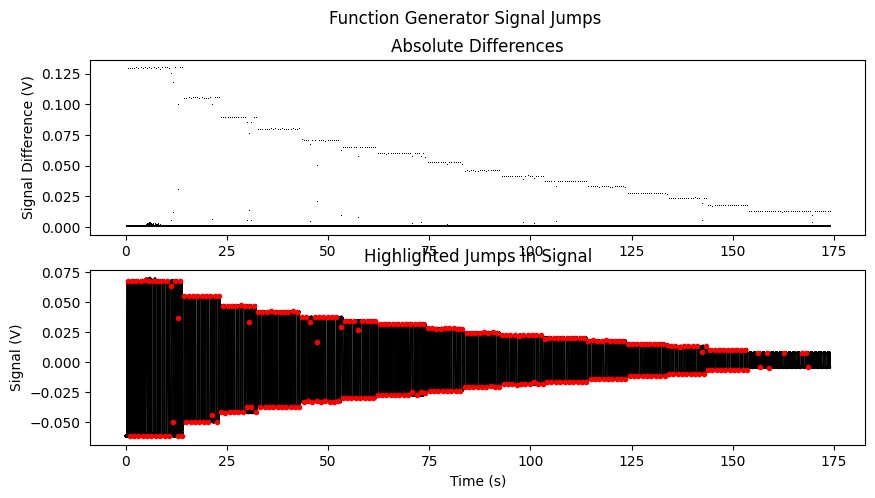

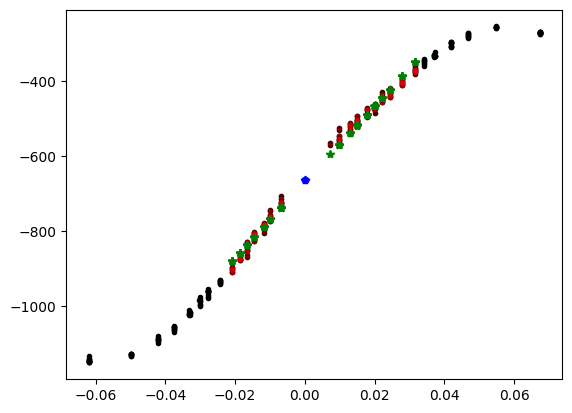

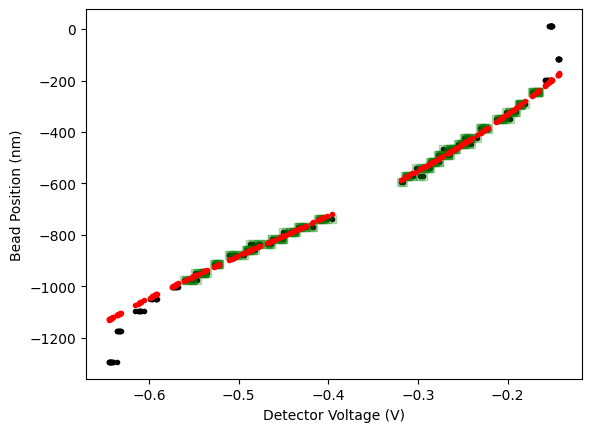

In [61]:
# data.reset_y()
data.calibrate_function_gen((3,(-1000, -200)),[-250e-9, 300e-9],['position', 'signal_jumps', 'lin_fit'])

In [ ]:
data.y

array([-3.29589844e-10, -3.29589844e-10, -3.29589844e-10, ...,
       -3.63769531e-10, -3.61328125e-10, -3.58886719e-10])

Frequency [1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00
 1.e+00 1.e+00 1.e+00 1.e+00 1.e+00 2.e+00 2.e+00 2.e+00 2.e+00 2.e+00
 2.e+00 2.e+00 2.e+00 2.e+00 3.e+00 3.e+00 3.e+00 3.e+00 3.e+00 3.e+00
 3.e+00 3.e+00 4.e+00 4.e+00 4.e+00 4.e+00 4.e+00 4.e+00 4.e+00 4.e+00
 5.e+00 5.e+00 5.e+00 5.e+00 5.e+00 5.e+00 6.e+00 6.e+00 6.e+00 6.e+00
 6.e+00 7.e+00 7.e+00 7.e+00 7.e+00 8.e+00 8.e+00 8.e+00 8.e+00 9.e+00
 9.e+00 9.e+00 9.e+00 9.e+00 1.e+01 1.e+01 1.e+01 2.e+01 2.e+01 2.e+01
 3.e+01 3.e+01 3.e+01 4.e+01 4.e+01 4.e+01 4.e+01 5.e+01 5.e+01 5.e+01
 6.e+01 6.e+01 6.e+01 7.e+01 7.e+01 7.e+01 8.e+01 8.e+01 8.e+01 8.e+01
 9.e+01 9.e+01 9.e+01 1.e+02 1.e+02 1.e+02 2.e+02 2.e+02 3.e+02 3.e+02
 3.e+02 4.e+02 4.e+02 5.e+02 5.e+02 5.e+02 6.e+02 6.e+02 6.e+02 7.e+02
 7.e+02 8.e+02 8.e+02 8.e+02 9.e+02 9.e+02 1.e+03 1.e+03 1.e+03 2.e+03
 2.e+03 3.e+03 4.e+03 4.e+03 4.e+03 5.e+03 5.e+03 6.e+03 6.e+03 7.e+03
 7.e+03 8.e+03 8.e+03 9.e+03 9.e+03]
Frequency changes: [ 14  23  3

/Users/coledebois/Altman lab/Altmanlab/experiment.py:625: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  times = dt*np.arange(len(avg_y))


function generator signal is empty for 121.5 - 121.0 seconds segment


/Users/coledebois/Altman lab/Altmanlab/experiment.py:656: OptimizeWarning: Covariance of the parameters could not be estimated
  if show_freq_plot:


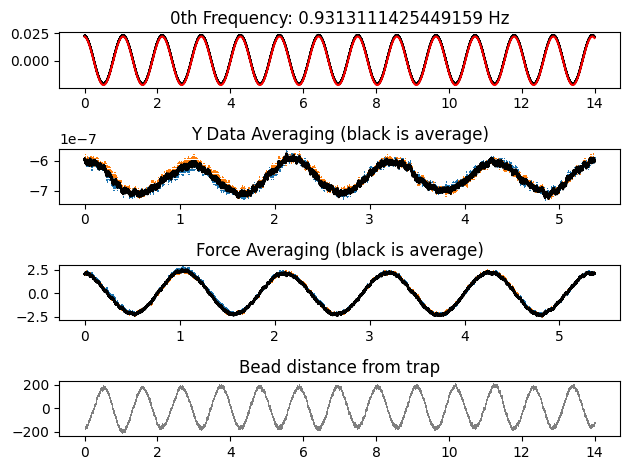

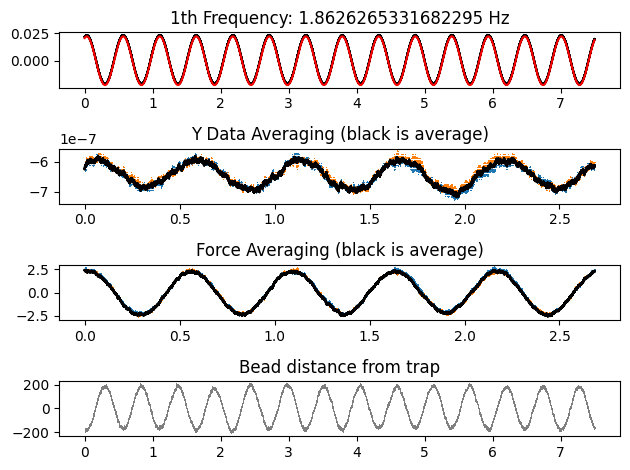

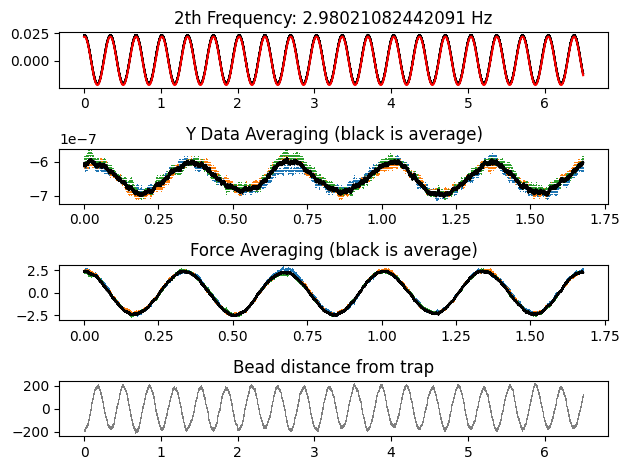

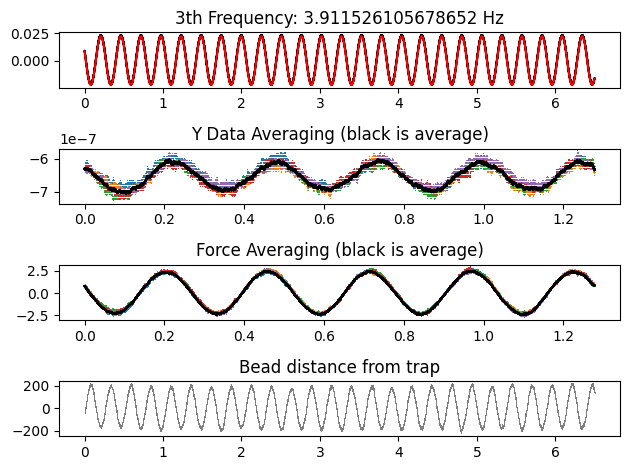

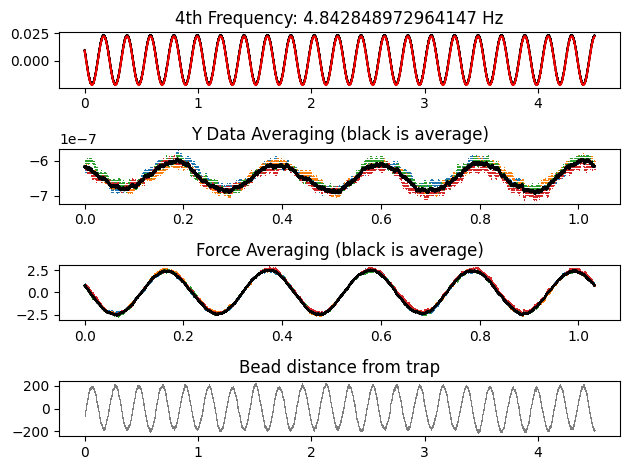

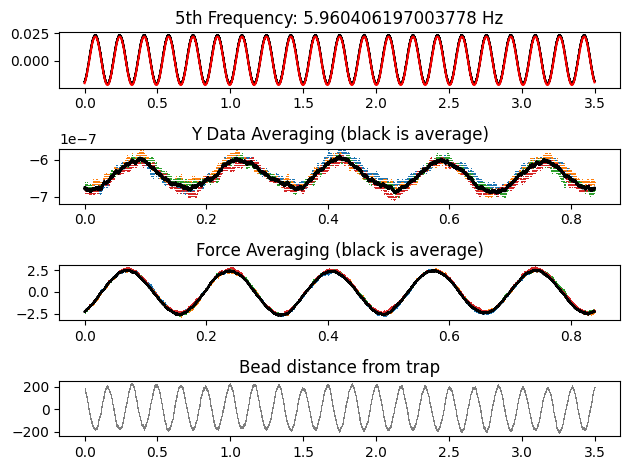

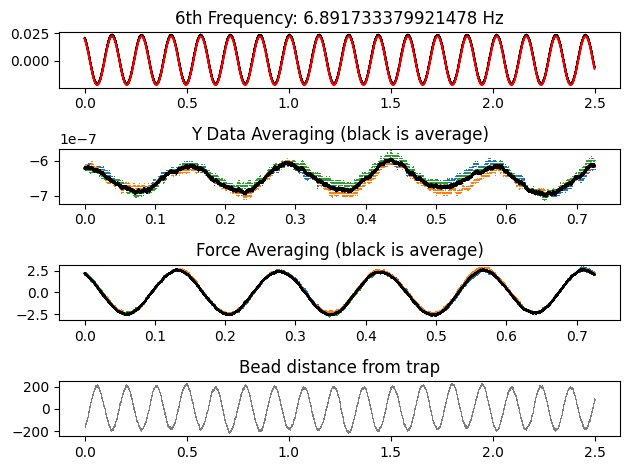

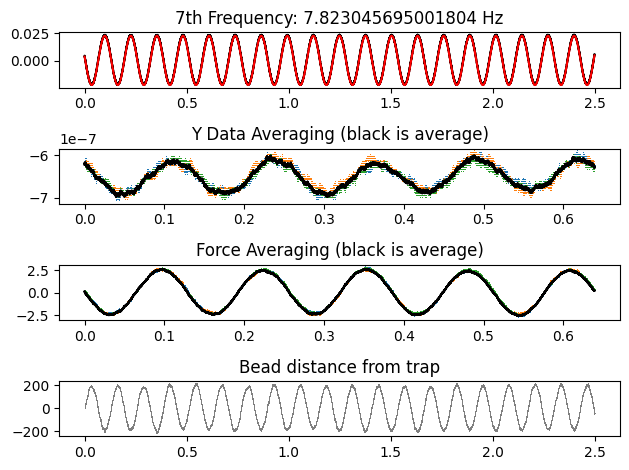

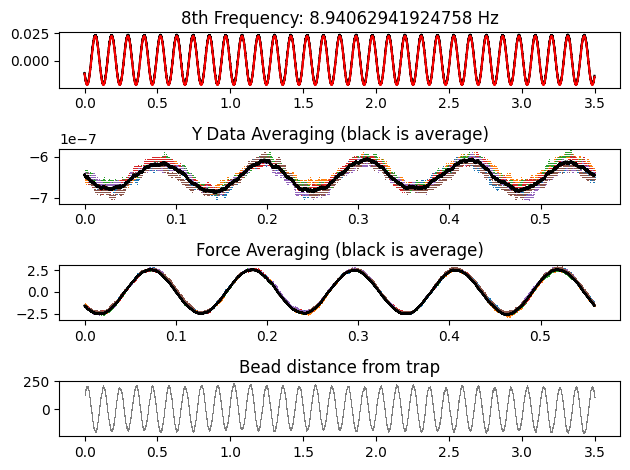

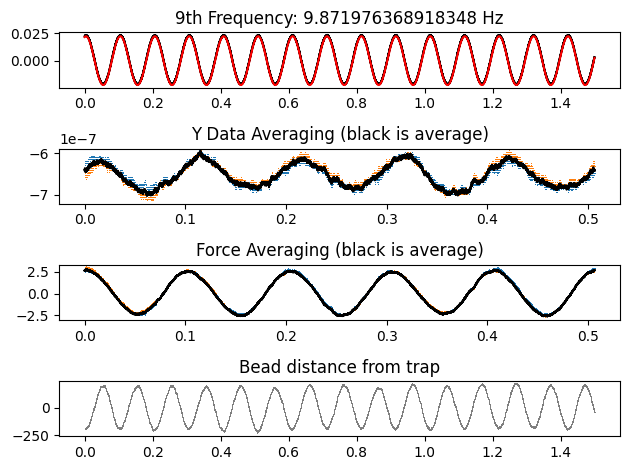

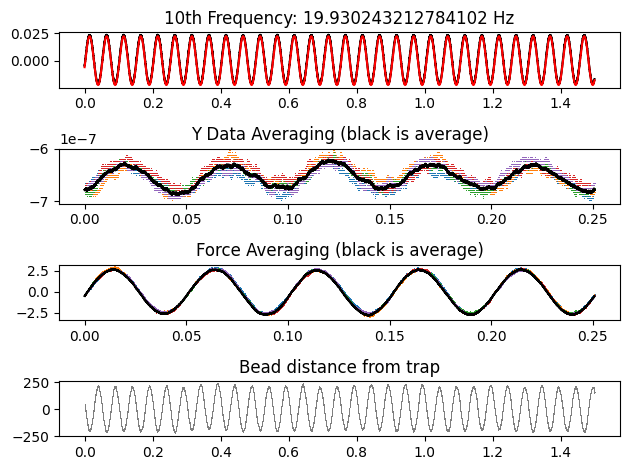

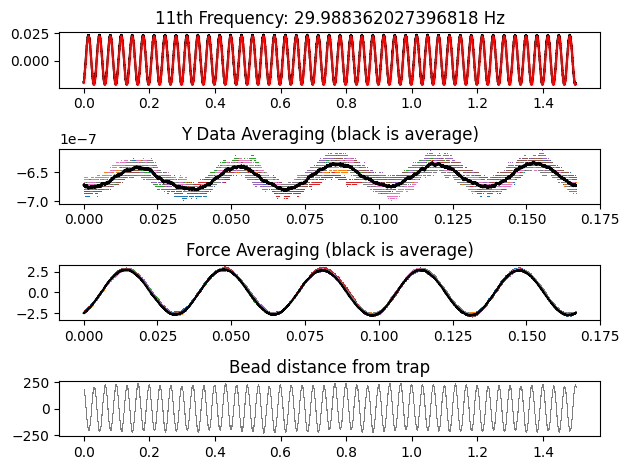

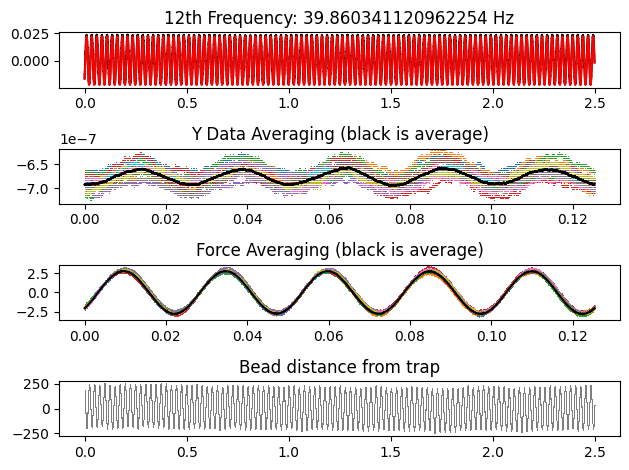

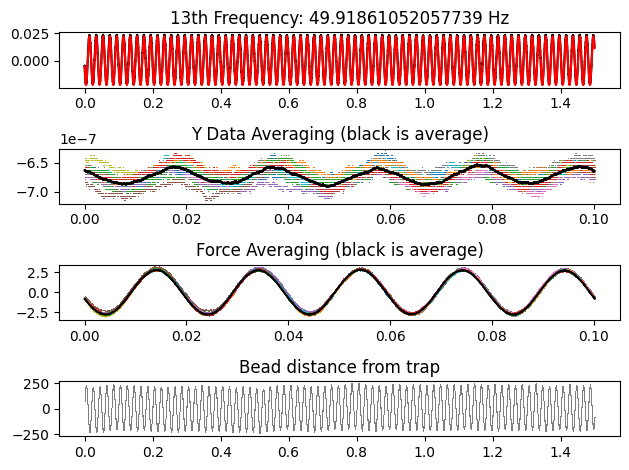

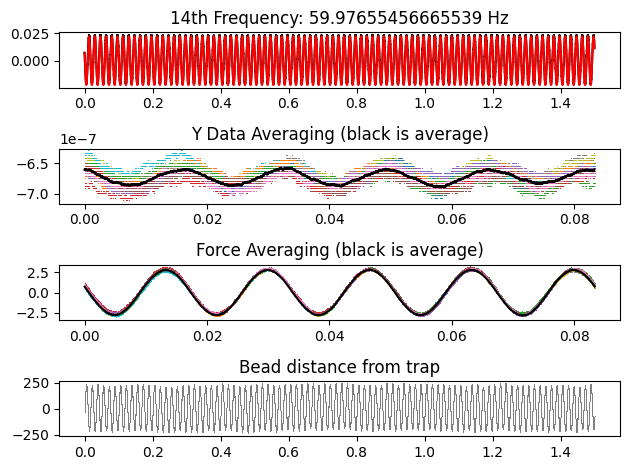

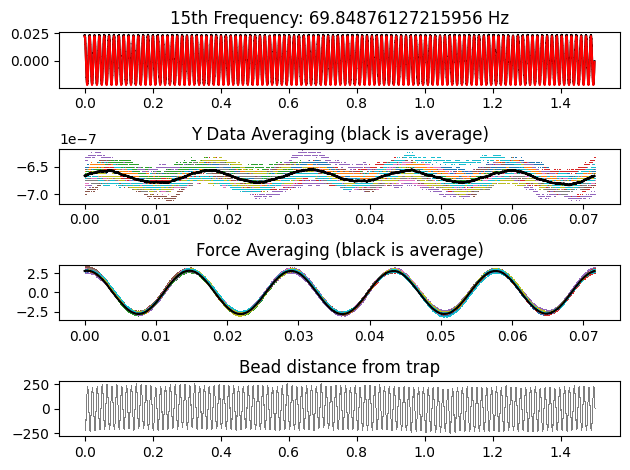

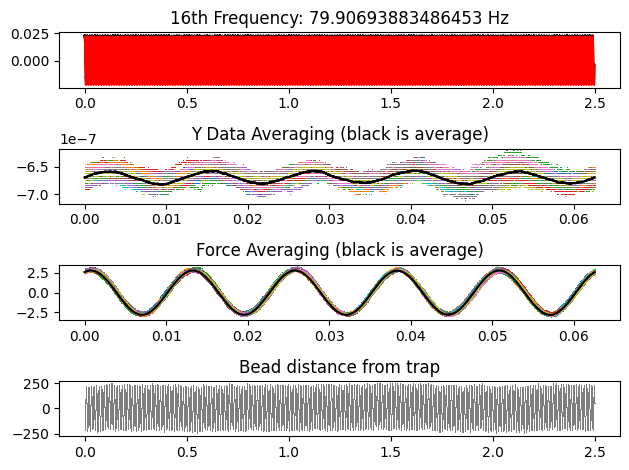

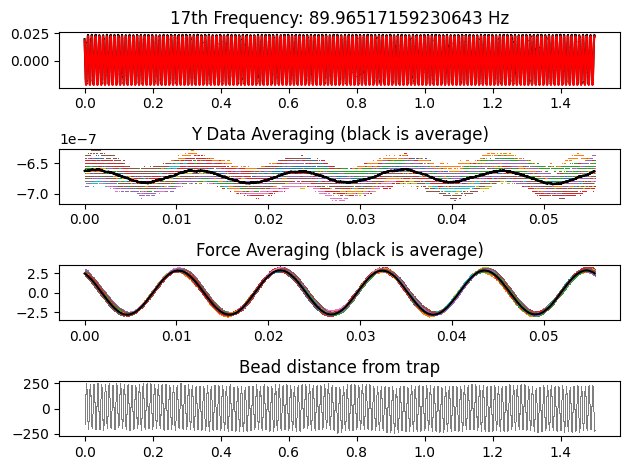

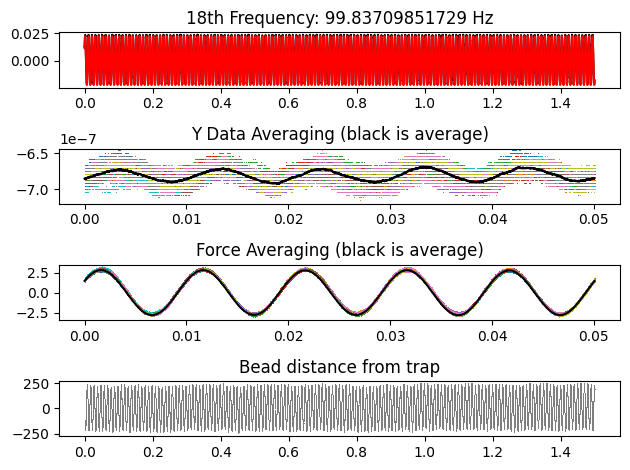

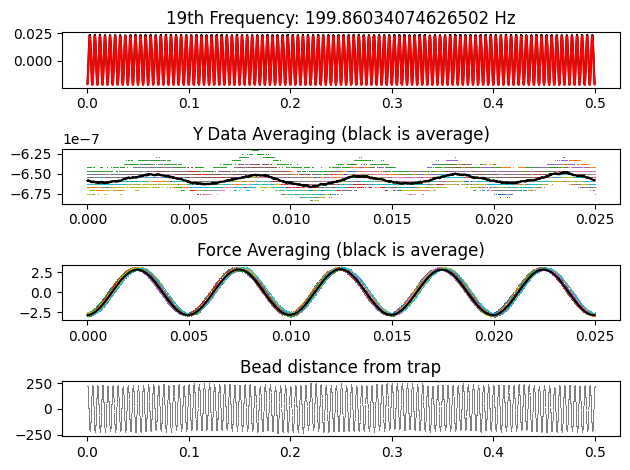

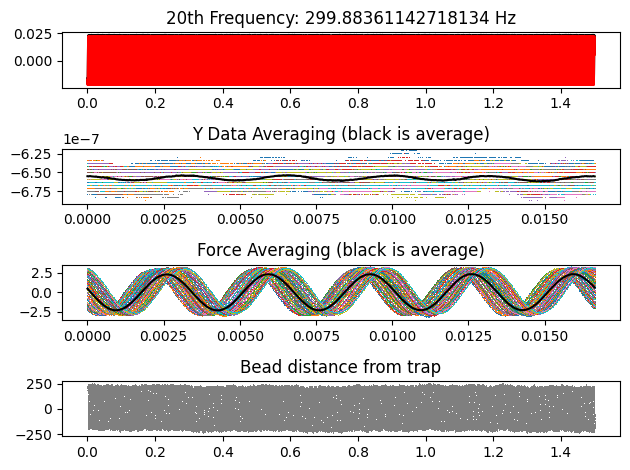

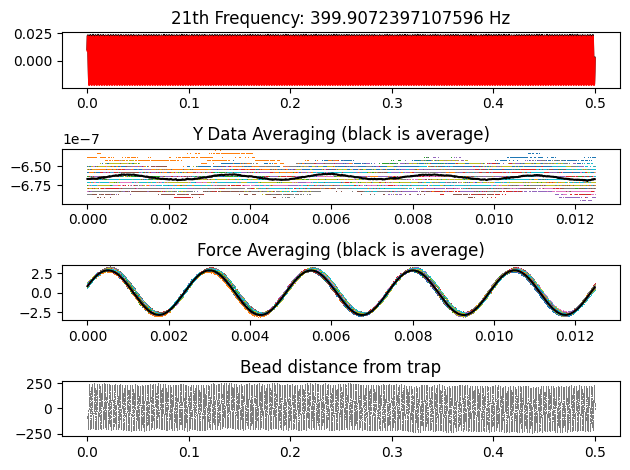

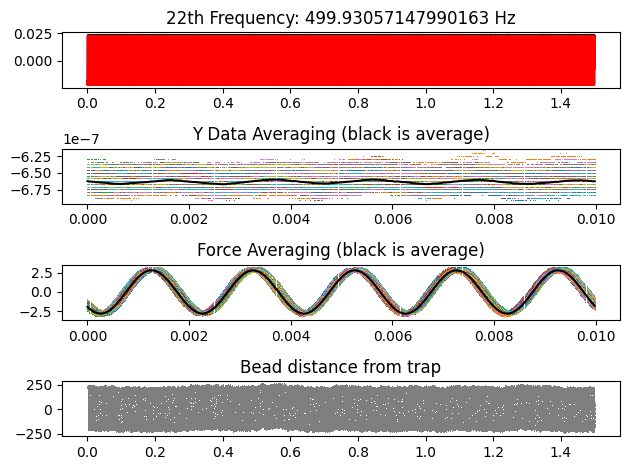

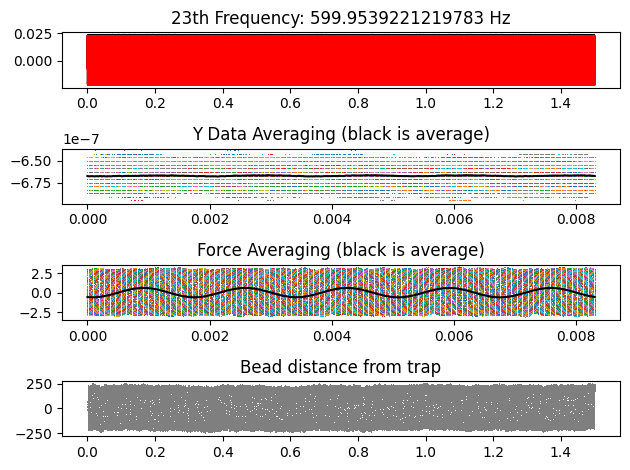

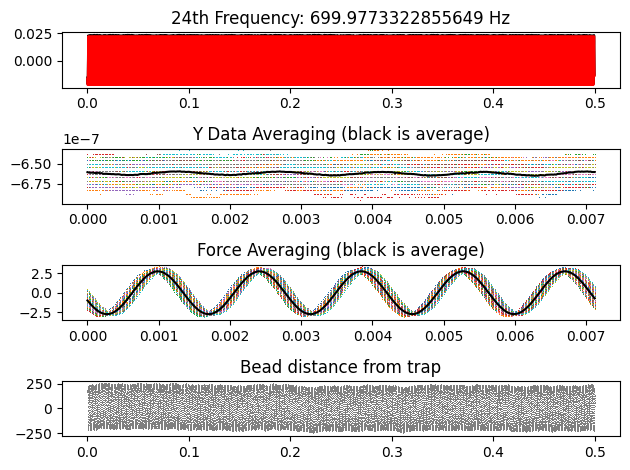

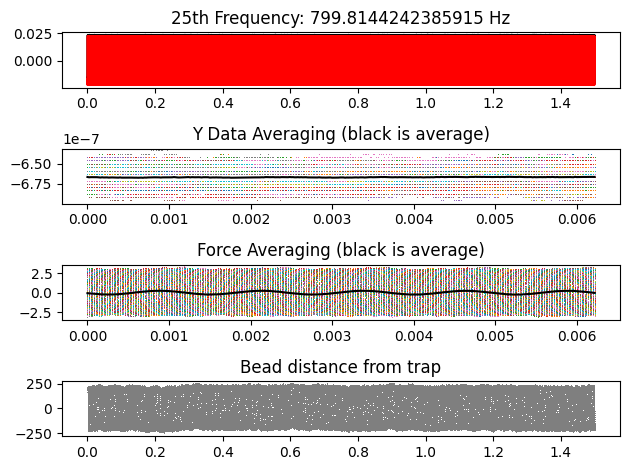

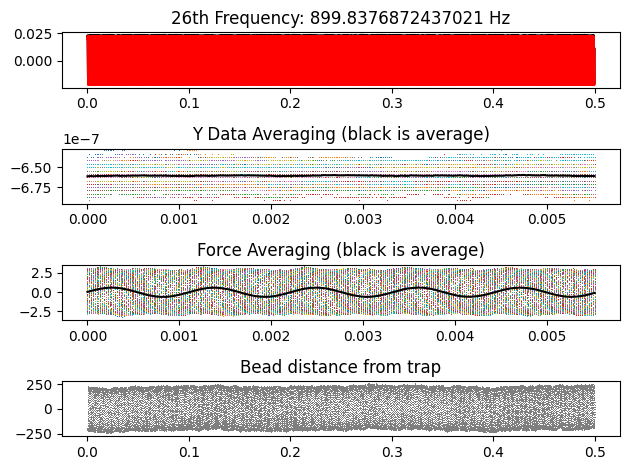

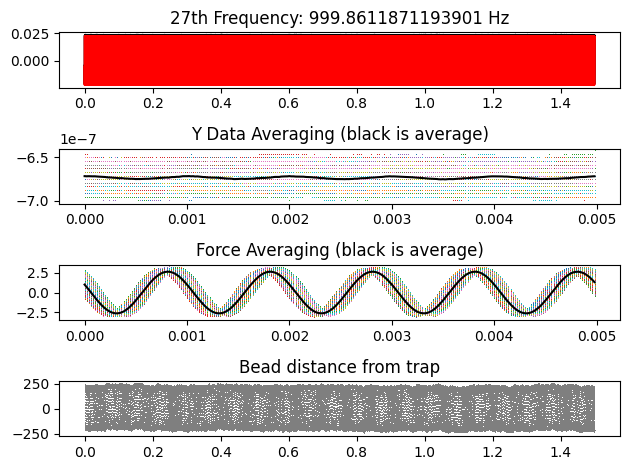

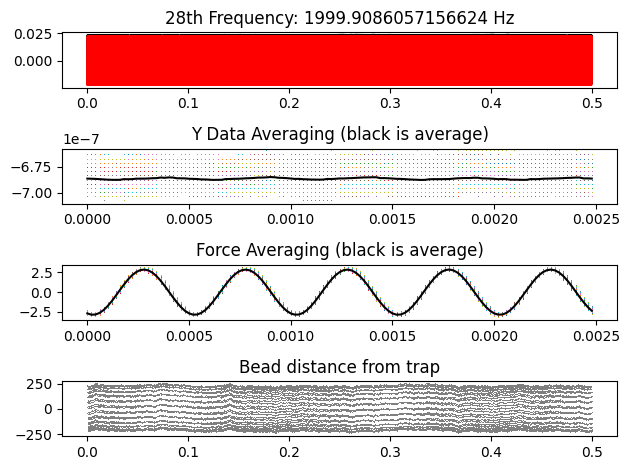

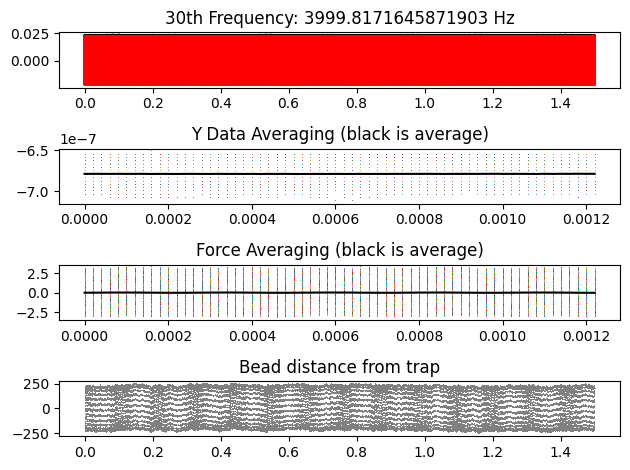

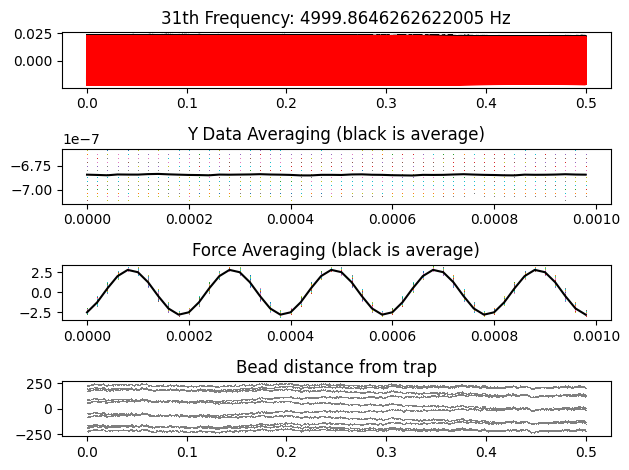

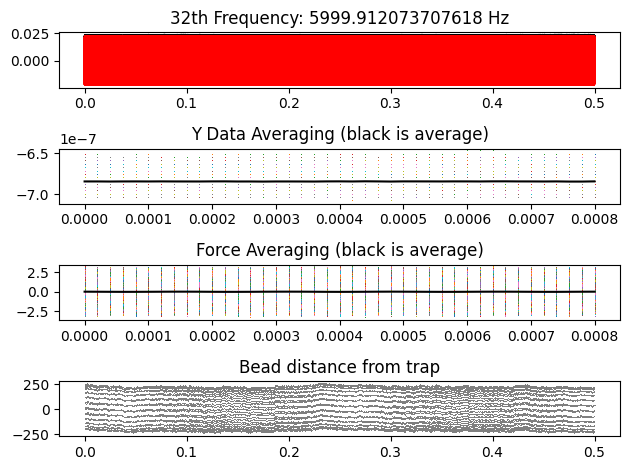

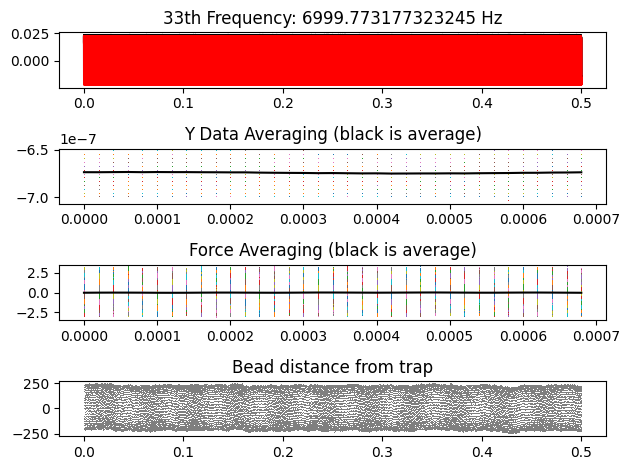

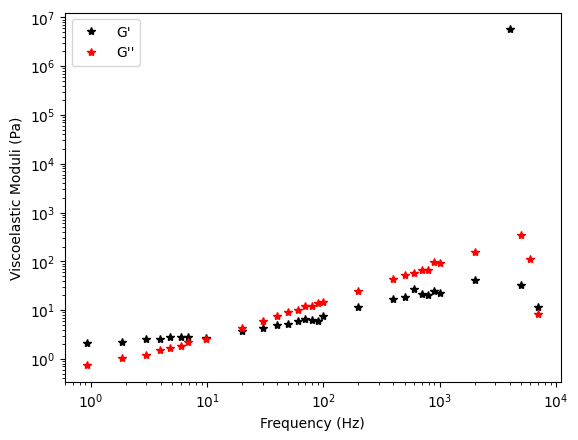

In [65]:
data.final_analysis()

In [ ]:
freq_list = data.freqlist * np.pi * 2
freq_list

33


In [73]:
freq_change = '14  23  31  39  45  50  54  58  63  66  69  72  76  79  82  85  89  92 95  97 100 102 105 108 110 113 115 118 124 126 128 130 132'.split()
freq_change = [int(i) for i in freq_change]
print(len(freq_change))

33


In [7]:
%reload_ext autoreload
%autoreload 2
from experiment import *
params = [
    820074.2474561329,
    560741.2730406355,
    1.2912493813158651e-05,
    1.2801834934988684e-05,
    -7.858806662560769e-08,
    -6.621915318362614e-07
]
datap = Passive_Analysis('250226/bead3p', params)

Calibration parameters:
Sx:  820074.2474561329
Sy:  560741.2730406355
kx:  1.2912493813158651e-05
ky:  1.2801834934988684e-05
trapx:  -7.858806662560769e-08
trapy:  -6.621915318362614e-07


499999
999998


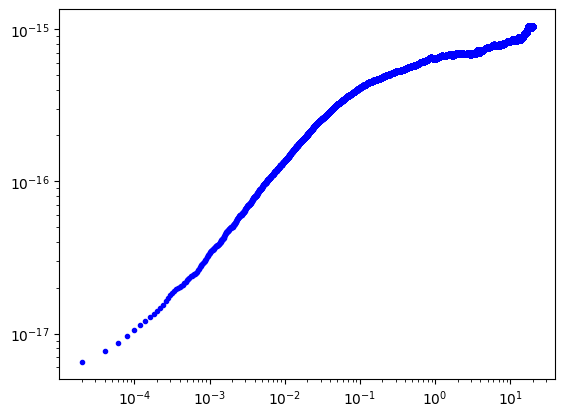

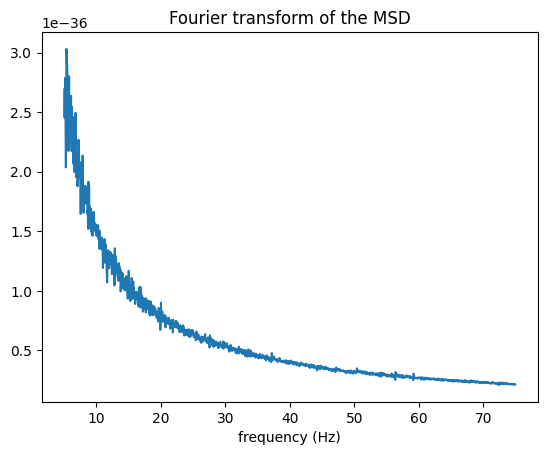

/Users/coledebois/.pyenv/versions/3.11.2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


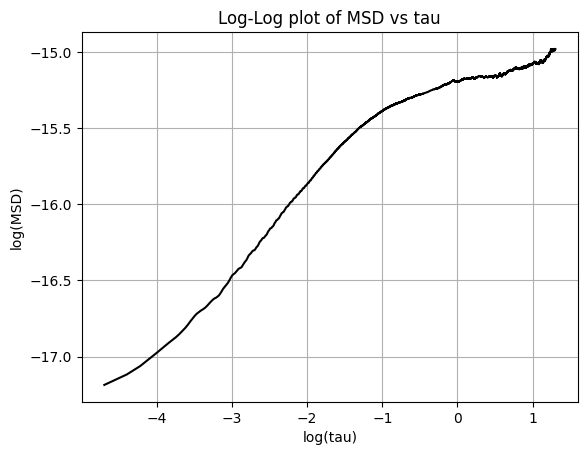

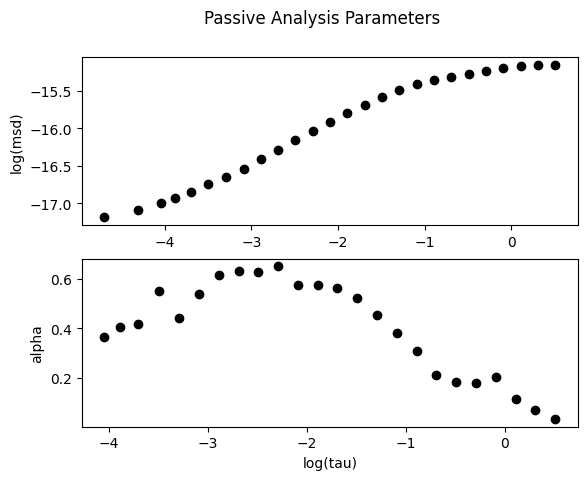

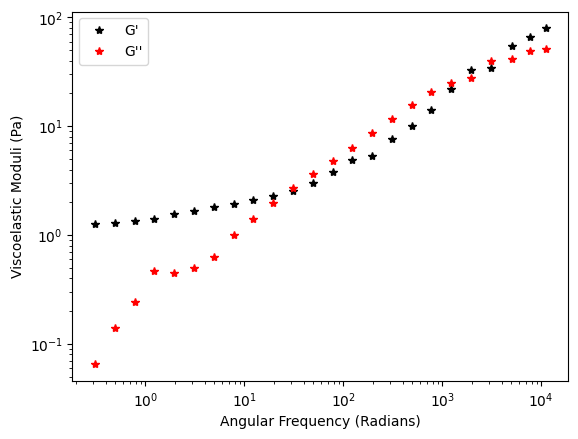

In [8]:
datap.final_analysis()

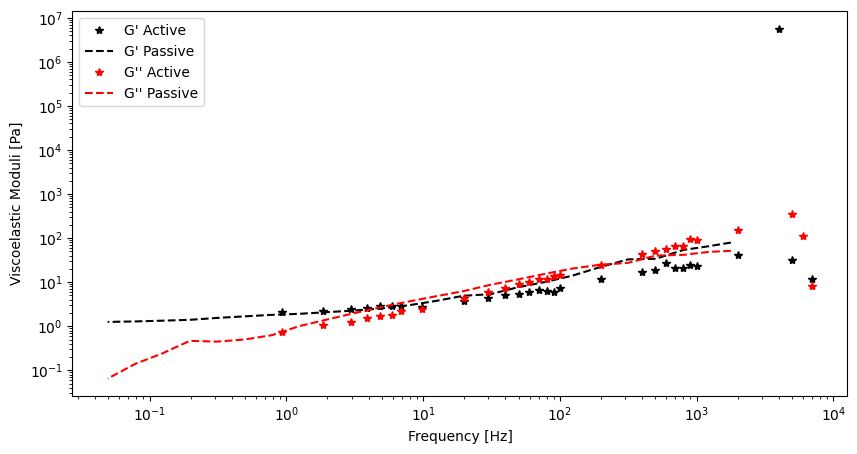

In [63]:
plt.figure(figsize=(10, 5))
plt.plot(data.freqlist,data.G1, 'k*', label='G\' Active')
plt.plot(datap.omegalist/(2*np.pi), datap.G1, 'k--', label='G\' Passive')
plt.plot(data.freqlist,data.G2, 'r*', label='G\'\' Active')
plt.plot(datap.omegalist/(2*np.pi), datap.G2, 'r--', label='G\'\' Passive')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Viscoelastic Moduli [Pa]')
plt.xscale('log')
plt.yscale('log')
plt.legend()